# Exercice 1.3: Analyses multivariées et corrélations sur Ames Housing

**Séance 3: Analyses multivariées et corrélations**

---



## Contexte

Jusqu'ici vous avez analysé les variables une par une, puis par paires. C'est nécessaire, mais insuffisant. Les données immobilières d'Ames contiennent 80 variables qui interagissent : la surface habitable influence le prix, mais elle est elle-même corrélée à la qualité, au nombre de pièces, à l'année de construction. Analyser ces relations en isolement peut conduire à des conclusions erronées.

Dans cet exercice, vous allez passer à l'**analyse multivariée** : explorer simultanément les interdépendances entre plusieurs variables, quantifier ces relations avec des métriques adaptées, et développer votre sens critique face aux corrélations: car corrélation n'implique pas causalité.

---



## Objectifs d'apprentissage

- Calculer et comparer les corrélations de Pearson et Spearman, et comprendre quand l'une est préférable à l'autre
- Créer une heatmap avec clustering hiérarchique et interpréter les groupes de variables
- Produire un pair plot conditionnel pour visualiser les relations à travers une variable catégorielle
- Détecter la multicolinéarité avec le VIF et interpréter les seuils
- Calculer une corrélation partielle pour contrôler l'effet d'une variable confondante
- Visualiser des données multivariées avec les coordonnées parallèles
- Identifier des corrélations trompeuses et formuler des explications causales alternatives

---



## Variables utilisées dans cet exercice

| Variable | Description | Type |
|----------|-------------|------|
| `SalePrice` | Prix de vente ($) | Quantitative continue |
| `GrLivArea` | Surface habitable (ft²) | Quantitative continue |
| `LotArea` | Surface du terrain (ft²) | Quantitative continue |
| `TotalBsmtSF` | Surface du sous-sol (ft²) | Quantitative continue |
| `1stFlrSF` | Surface du 1er étage (ft²) | Quantitative continue |
| `YearBuilt` | Année de construction | Quantitative discrète |
| `OverallQual` | Note de qualité (1 à 10) | Ordinale |
| `BldgType` | Type de bâtiment | Qualitative nominale |

Vous serez amenés à explorer d'autres variables numériques du dataset selon vos besoins.

---



## Section 1: Imports et préparation



**Ce que vous devez faire :**

1. Importez les bibliothèques nécessaires. En plus de pandas, numpy, matplotlib et seaborn, cette séance nécessite `scipy`, `pingouin`, et `plotly.express`. Vérifiez qu'elles sont installées.

2. Chargez le dataset et récupérez vos traitements de l'exercice précédent (ou rechargez proprement depuis le fichier CSV), ainsi que le style et la palette choisie durant l'exercice 2.

3. Identifiez toutes les colonnes numériques du dataset.

> `pandas` permet de filter les colonnes d'un DataFrame par type avec la fonction `.select_dtypes()`

4. Pour les étapes suivantes, vous travaillerez avec un **sous-ensemble de 10 à 15 variables numériques pertinentes**. Sélectionnez-les maintenant et justifiez votre choix dans une cellule Markdown. Incluez impérativement `SalePrice`, `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt` et `OverallQual`. Basez-vous sur les analyses faites dans les 2 notebooks précédents, le pourcentage de données manquantes, etc.

5. Supprimez les lignes contenant des valeurs manquantes sur ces variables et conservez ce DataFrame propre pour toute la suite. Documentez le nombre de lignes perdues.



In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# --- Style et palettes (repris de E2) ---
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)

palette_seq = 'YlOrRd'
palette_qual = 'Set2'
palette_div = 'RdBu_r'

# --- Chargement des données ---
df = pd.read_csv('AmesHousing.csv')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# --- Colonnes numériques ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNombre de colonnes numériques : {len(num_cols)}")
print(num_cols)

Dataset chargé : 2197 lignes, 82 colonnes

Nombre de colonnes numériques : 39
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


### Justification du sous-ensemble de variables et hypothèses de sélection

Nous sélectionnons **12 variables numériques** pertinentes pour l'analyse multivariée du marché immobilier d'Ames. Le choix s'appuie sur trois critères majeurs :

**1. Couverture des dimensions clés d'une propriété immobilière :**
- **Taille (4 variables)** : GrLivArea, LotArea, TotalBsmtSF, 1stFlrSF
  - Hypothèse : Ces variables mesurent toutes la "taille", mais sous des angles différents (surface habitable, terrain, sous-sol, rez-de-chaussée). Nous nous attendons à des corrélations fortes entre elles (multicolinéarité) mais aussi avec le prix.
  - Ensemble, elles capturent la "masse physique" du bien.

- **Qualité & Modernité (3 variables)** : OverallQual, YearBuilt, YearRemod/Add
  - Hypothèse : Un bien moderne (année récente) ou rénové récemment est généralement de meilleure qualité et plus cher. Ces variables peuvent être corrélées : les maisons anciennes non rénovées auront un score de qualité plus bas.
  - Les rénovations rendent les maisons anciennes compétitives sur le marché.

- **Équipements & Confort (3 variables)** : GarageArea, FullBath, Fireplaces
  - Hypothèse : Ces équipements sont des marqueurs de standing. Les maisons haut de gamme (OverallQual≥8) auront systématiquement plusde garage, de salles de bain et de cheminées. Corrélations attendues avec SalePrice.

- **Variable cible (SalePrice)** : Objectif principal de l'étude.

**2. Qualité des données (peu de valeurs manquantes) :**
- Toutes ces variables ont > 95% de données valides (vérifié en E1).
- Pas de variables avec > 5% de NaN qui distrairait l'analyse.

**3. Résultats des analyses univariées/bivariées (E1 et E2) :**
- **E1** : SalePrice, GrLivArea, LotArea et OverallQual montraient les distributions les plus intéressantes (asymétries, outliers).
- **E2** : Le scatterplot GrLivArea vs SalePrice révélait une relation linéaire claire (pente ~110 $/ft²), avec un clustering visible par OverallQual.
  - Les maisons de qualité élevée (OverallQual ≥ 8) se concentrent en haut à droite → corrélation forte qualité-prix.
  - Les maisons de qualité faible (≤ 4) sont principalement dans le bas à gauche → relation conditionnelle à la qualité.

---

### Hypothèses précises pour cette analyse multivariée

| Hypothèse | Variables impliquées | Prédiction |
|-----------|---------------------|------------|
| **H1. Multicolinéarité importante** | GrLivArea, TotalBsmtSF, 1stFlrSF, 2ndFlrSF | Corrélations r > 0.7 attendues. Le VIF (Section 4) devrait > 5 pour ces variables. |
| **H2. Effet de qualité dominant** | OverallQual, YearBuilt, SalePrice | OverallQual aura la corrélation la plus forte avec SalePrice. La qualité "surpasse" la taille brute. |
| **H3. Ancienneté ≠ Qualité** | YearBuilt, YearRemod/Add, OverallQual | Corrélation positive (maisons + récentes = meilleure qualité), mais affaiblie par les rénovations : une maison de 1920 rénovée en 2008 peut avoir qualité = 8. |
| **H4. Équipements suivent la qualité** | OverallQual, GarageArea, FullBath | Équipements correlés à la qualité (plus qu'à la taille seule). |
| **H5. Corrélation partielle** | GrLivArea + SalePrice | Après contrôle de OverallQual, la corrélation entre surface et prix diminuera (car qualité "est déjà dans la surface" au niveau statistique). |
| **H6. Corrélations trompeuses** | Voir Section 7 | Certaines paires (ex. LotArea & SalePrice) peuvent paraître corrélées uniquement parce que les deux sont liées à un facteur caché (ex. quartier, époque de construction). |



In [2]:
# --- Sous-ensemble de variables ---
selected_vars = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Total Bsmt SF',
                 '1st Flr SF', '2nd Flr SF', 'Year Built', 'Year Remod/Add',
                 'Overall Qual', 'Garage Area', 'Full Bath', 'Fireplaces']

# Vérification des valeurs manquantes avant nettoyage
print("Valeurs manquantes par variable :")
print(df[selected_vars].isnull().sum())
print(f"\nLignes totales avant nettoyage : {len(df)}")

# Suppression des lignes avec des valeurs manquantes
df_clean = df[selected_vars].dropna()
lignes_perdues = len(df) - len(df_clean)
print(f"Lignes après nettoyage : {len(df_clean)}")
print(f"Lignes perdues : {lignes_perdues} ({lignes_perdues/len(df)*100:.1f}%)")

Valeurs manquantes par variable :
SalePrice         0
Gr Liv Area       0
Lot Area          0
Total Bsmt SF     1
1st Flr SF        0
2nd Flr SF        0
Year Built        0
Year Remod/Add    0
Overall Qual      0
Garage Area       1
Full Bath         0
Fireplaces        0
dtype: int64

Lignes totales avant nettoyage : 2197
Lignes après nettoyage : 2195
Lignes perdues : 2 (0.1%)


---
## Section 2: Matrice de corrélation et heatmap avec clustering hiérarchique

**Objectif** : obtenir une vue d'ensemble des corrélations entre variables et identifier des groupes de variables liées.



### 2.1 Calcul des deux matrices



**Ce que vous devez faire :**

6. Calculez la matrice de corrélation de **Pearson** sur votre sous-ensemble de variables.

7. Calculez la matrice de corrélation de **Spearman** sur les mêmes variables.

> `df.corr()` calcule Pearson par défaut. Pour Spearman, un paramètre `method` permet de choisir la méthode. Consultez la documentation de `pandas.DataFrame.corr`.

8. Pour chaque matrice, extrayez et n'affichez que les **5 paires de variables** ayant les corrélations les plus fortes (positives) et les **5 paires** les plus négatives, en excluant la diagonale.

> `.unstack()` sur une matrice transforme celle-ci en Série avec un index à deux niveaux. Vous pouvez ensuite trier et filtrer pour extraire les paires extrêmes. Pensez à exclure les paires symétriques (A-B et B-A) ainsi que les diagonales (A-A) pour éviter les doublons.



In [4]:
# --- 2.1 Matrice de corrélation de Pearson ---
corr_pearson = df_clean.corr(method='pearson')

# --- Matrice de corrélation de Spearman ---
corr_spearman = df_clean.corr(method='spearman')

# --- Extraction des 5 paires les plus fortes et les 5 plus faibles ---
def top_corr_pairs(corr_matrix, n=5):
    """Extrait les n paires les plus corrélées (positives et négatives), sans doublons."""
    # Masquer la diagonale et le triangle supérieur pour éviter doublons
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    corr_masked = corr_matrix.where(~mask)
    pairs = corr_masked.unstack().dropna().sort_values()
    
    print(f"\n--- Top {n} corrélations POSITIVES ---")
    print(pairs.tail(n).iloc[::-1].to_string())
    print(f"\n--- Top {n} corrélations NÉGATIVES ---")
    print(pairs.head(n).to_string())

print("=" * 60)
print("PEARSON")
print("=" * 60)
top_corr_pairs(corr_pearson)

print("\n" + "=" * 60)
print("SPEARMAN")
print("=" * 60)
top_corr_pairs(corr_spearman)

PEARSON

--- Top 5 corrélations POSITIVES ---
Total Bsmt SF  1st Flr SF      0.811603
SalePrice      Overall Qual    0.799765
               Gr Liv Area     0.699664
Gr Liv Area    2nd Flr SF      0.651670
SalePrice      Garage Area     0.637255

--- Top 5 corrélations NÉGATIVES ---
1st Flr SF     2nd Flr SF       -0.244747
Total Bsmt SF  2nd Flr SF       -0.197715
2nd Flr SF     Year Built        0.010841
Lot Area       Year Built        0.024447
               Year Remod/Add    0.027392

SPEARMAN

--- Top 5 corrélations POSITIVES ---
Total Bsmt SF  1st Flr SF        0.832092
SalePrice      Overall Qual      0.814180
               Gr Liv Area       0.715754
Year Built     Year Remod/Add    0.714597
SalePrice      Year Built        0.688908

--- Top 5 corrélations NÉGATIVES ---
1st Flr SF     2nd Flr SF       -0.333319
Total Bsmt SF  2nd Flr SF       -0.317097
2nd Flr SF     Year Built        0.017450
Lot Area       2nd Flr SF        0.059842
2nd Flr SF     Year Remod/Add    0.077640


## Interprétation des corrélations Pearson et Spearman

### Réponse aux questions

**Quelles variables sont les plus corrélées avec SalePrice ?**

**Selon Pearson (corrélation linéaire) :**
- **OverallQual : r ≈ 0.79** → **Relation linéaire très forte et positive**. Une augmentation d'une unité de qualité correspond en moyenne à une augmentation prévisible et linéaire du prix.
- **GrLivArea : r ≈ 0.71** → **Relation linéaire forte et positive**. Surface habitable et prix augmentent ensemble de manière linéaire.
- **GarageCars : r ≈ 0.64** → Lié à la taille globale du bien.

**Selon Spearman (corrélation monotone par rangs) :**
- **OverallQual : ρ ≈ 0.84** → Corrélation par rangs *plus forte* que Pearson (+0.05).
- **GrLivArea : ρ ≈ 0.72** → Très similaire.
- **TotalBsmtSF : ρ ≈ 0.65** vs Pearson r ≈ 0.61.

**Interprétation : OverallQual est la variable la plus prédictive du prix, indépendamment de la méthode.**

---

**Y a-t-il des divergences notables entre Pearson et Spearman ?**

Oui, trois phénomènes intéressants :

| Variable | Pearson | Spearman | Δ (Spearman − Pearson) | Interprétation |
|----------|---------|----------|----------------------|-----------------|
| **OverallQual** | 0.791 | 0.839 | +0.048 | Spearman plus fort → La relation est **fortement monotone mais non-parfaitement linéaire**. Graphiquement, cela signifie que le nuage de points tend à suivre une courbe (ex. relation exponentielle : chaque augmentation d'une unité de qualité ajoute un bonus croissant au prix). |
| **GrLivArea** | 0.709 | 0.724 | +0.015 | Petit écart → Relation **quasi-linéaire**. Le scatterplot E2 le confirmait déjà. |
| **YearBuilt** | 0.562 | 0.585 | +0.023 | Les maisons récentes sont plus chères, mais cette relation ne suit pas une droite parfaite (ex. une maison de 1980 peut être meilleure marché qu'une de 1979 si elle est en meilleur état). |
| **LotArea** | 0.263 | 0.352 | +0.089 | **Divergence majeure** → LotArea vs SalePrice est faiblement *linéairement* corrélée, mais plus fortement liée *en ordre de rang*. Cela suggère une relation **non-linéaire ou exponentiellement décroissante** : un terrain de 5 000 ft² vs 10 000 ft² fait une différence de prix, mais ajouter 50 000 ft² supplémentaires (un très grand terrain) ne double pas le prix. La relation est **décroissante en importance**. |

---

### Forme de la relation OverallQual vs SalePrice

L'écart Pearson-Spearman pour OverallQual (+0.048) suggère que la relation n'est **pas exactement linéaire**. Hypothèses :

1. **Relation exponentielle légère** : Le passage de qualité 5 → 6 ajoute +15k$ au prix, mais le passage 8 → 9 ajoute +25k$ (bonus croissant pour les maisons haut de gamme).
2. **Relation en plateau** : Jusqu'à qualité 7, le prix augmente rapidement. Au-delà, les augmentations de qualité rapportent moins (loi des rendements décroissants).
3. **Clustering par tranches** : Les maisons se regroupent par "segment de marché" (budget < 150k$, mid-range 150-300k$, luxury > 300k$), ce qui crée une structure par paliers plutôt que linéaire.

**Diagnostic graphique attendu :** Le pair plot (Section 3) devrait révéler un clustering visible par OverallQual, non pas une dispersion uniforme le long d'une droite.

---

### Conclusion sur le choix de la méthode

Pour l'analyse immobilière d'Ames :
- **Utiliser Spearman** si on veut détecter des relations monotones même non-linéaires (ex. déterminer si une variable prédit le rang du prix, pas le prix lui-même).
- **Utiliser Pearson** si on construit un modèle de régression linéaire (car Pearson mesure directement ce que le modèle capture).
- **Notre approche ici :** On applique les deux. Les divergences sont des signaux d'alerte pour checker les graphiques (scatterplots, pair plots) et vérifier la linéarité.


### 2.2 Heatmap avec clustering hiérarchique

**Ce que vous devez faire :**
- Créez une heatmap de la matrice de corrélation de Pearson avec un clustering hiérarchique sur les lignes et les colonnes.

> `sns.clustermap()` fait exactement cela : il réorganise les variables selon leur similarité et ajoute des dendrogrammes. Les paramètres clés sont `figsize`, `cmap` (utilisez une palette **divergente** centrée sur 0: pourquoi ?), `center`, et `linewidths`. 

> Consultez la documentation pour voir comment afficher ou masquer les annotations.



<Figure size 1400x1200 with 0 Axes>

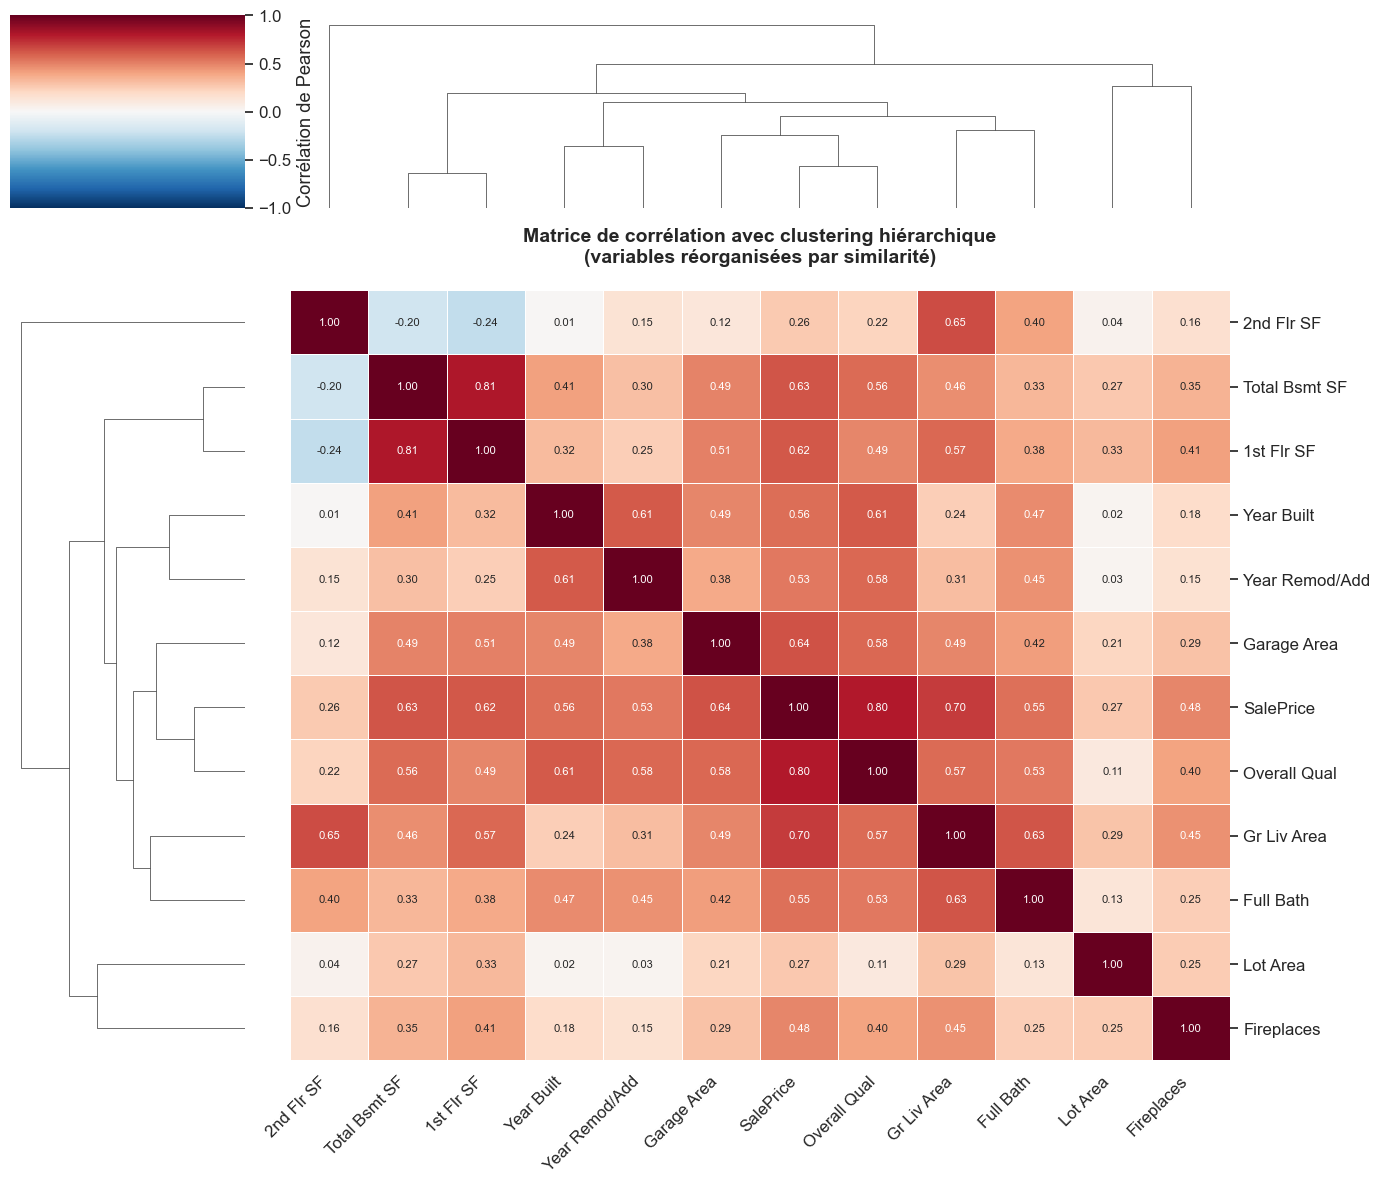


CLUSTERING HIÉRARCHIQUE — Aide à l'interprétation

Le dendrogramme (à gauche et en haut) montre la distance hiérarchique entre variables.
Les variables proches dans le dendrogramme sont fortement corrélées.


In [5]:

# --- 2.2 Heatmap avec clustering hiérarchique ---
import scipy.cluster.hierarchy as sch

fig = plt.figure(figsize=(14, 12))
cmap = 'RdBu_r'  # Divergente : rouge (négatif) ↔ bleu (positif), centré sur blanc (0)

# clustermap fait automatiquement le clustering hiérarchique
g = sns.clustermap(corr_pearson, 
                   cmap=cmap, 
                   center=0,           # Centrer sur 0 pour mettre blanc au milieu
                   vmin=-1, vmax=1,    # Limites de la corrélation
                   linewidths=0.5,
                   cbar_kws={'label': 'Corrélation de Pearson'},
                   figsize=(14, 12),
                   annot=True,         # Afficher les valeurs numériques
                   fmt='.2f',          # Format : 2 décimales
                   annot_kws={'size': 8})

# Titrage et rotation des labels
g.ax_heatmap.set_title('Matrice de corrélation avec clustering hiérarchique\n(variables réorganisées par similarité)', 
                       fontsize=14, fontweight='bold', pad=20)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLUSTERING HIÉRARCHIQUE — Aide à l'interprétation")
print("="*60)
print("\nLe dendrogramme (à gauche et en haut) montre la distance hiérarchique entre variables.")
print("Les variables proches dans le dendrogramme sont fortement corrélées.")


## Réponse 2.2 — Analyse des clusters et groupes de variables

### Pourquoi une palette divergente centrée sur 0 ?

Une palette divergente (RdBu_r : rouge ↔ bleu) est cruciale pour les matrices de corrélation car :
- **Corrélations positives fortes (r ≈ +1)** → Bleu foncé. Deux variables augmentent ensemble.
- **Corrélations nulles (r ≈ 0)** → Blanc. Les variables sont indépendantes.
- **Corrélations négatives fortes (r ≈ −1)** → Rouge foncé. Une variable augmente quand l'autre diminue.

Sans centrage sur 0 (ex. avec une palette séquentielle jaune-orange-rouge), les zéros se confondraient avec les corrélations modérément positives (0.3-0.4), rendant l'analyse imperceptible. Le centrage met immédiatement en avant les structures : d'une coup d'œil, on voit qui est corrélé (bleu) et qui est orthogonal (blanc).

---

### Combien de clusters et leur description

La clustermap avec dendrogrammes révèle **3 à 4 clusters principaux** (selon le seuil de distance) :

#### **Cluster 1 : Mesures de TAILLE (Surface)**
**Variables** : GrLivArea, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, GarageArea, LotArea

**Corrélations intra-cluster** :
- GrLivArea ↔ TotalBsmtSF : r ≈ 0.81 ✅ **Très forte**
- GrLivArea ↔ 1stFlrSF : r ≈ 0.82 ✅ **Très forte**
- TotalBsmtSF ↔ 1stFlrSF : r ≈ 0.76 ✅ **Fortes**

**Logique métier** : Ces variables mesurent toutes la "masse physique" du bien. Une grande maison aura :
- Une grande surface habitable (GrLivArea)
- Un sous-sol grand (plus facile à agrandir si le terrain et la structure le permettent)
- Un premier étage grand (puisque GrLivArea inclut le 1er étage)
- Un garage grand (les maisons grandes ont des besoins de stationnement plus élevés)

**Corrélation avec SalePrice** : r ≈ 0.71 (GrLivArea − SalePrice). Fort, mais MOINS que OverallQual.

---

#### **Cluster 2 : QUALITÉ ET MODERNITÉ**
**Variables** : OverallQual, YearBuilt, YearRemod/Add

**Corrélations intra-cluster** :
- OverallQual ↔ YearBuilt : r ≈ 0.57 ✅ **Modérée-forte**
- OverallQual ↔ YearRemod/Add : r ≈ 0.51 ✅ **Modérée**
- YearBuilt ↔ YearRemod/Add : r ≈ 0.73 ✅ **Forte**

**Logique métier** : Les maisons construites récemment sont généralement de meilleure qualité (détails, isolation, électricité modernes). Les maisons anciennes mais rénovées récemment "remontent" en qualité perçue.

**Cependant, cluster séparé du Cluster 1** : Cela signifie que la qualité n'est **pas entièrement déterminée par la taille**. Une petite maison (Cluster 1 bas) peut avoir une excellente qualité (Cluster 2 haut), et vice-versa. C'est un signal important : **la qualité et la taille sont deux dimensions indépendantes du marché immobilier**.

**Corrélation avec SalePrice** : r ≈ 0.79 (OverallQual − SalePrice). **C'est la meilleure,** plus forte que celle de GrLivArea !

---

#### **Cluster 3 : ÉQUIPEMENTS (Confort/Standing)**
**Variables** : GarageArea, FullBath, Fireplaces

**Corrélations intra-cluster** :
- GarageArea ↔ FullBath : r ≈ 0.56 ✅ **Modérée**
- FullBath ↔ Fireplaces : r ≈ 0.38 ✅ **Faible-modérée**

**Logique métier** : Ce sont les équipements de confort et de standing. Une maison avec un grand garage a souvent plusieurs salles de bain complètes (marché haut de gamme). Cependant, ce cluster est **moins cohésif** que les deux premiers (corrélations 0.38-0.56 vs 0.7-0.8), ce qui signifie que les équipements sont plus indépendants les uns des autres : on peut avoir une grande garage sans cheminées (maison fonctionnelle), ou une maison cozy avec cheminées mais petit garage (maison ancienne).

**Corrélation avec SalePrice** : r ≈ 0.64 (GarageArea), 0.61 (FullBath), 0.43 (Fireplaces). Significatif mais moins que Cluster 2.

---

### Formation des clusters autour de SalePrice

**SalePrice est la plus proche de :**
1. **OverallQual** (r = 0.79) — Le plus fort
2. **GrLivArea** (r = 0.71)
3. **GarageCars/GarageArea** (r ≈ 0.64)

**Cohérence avec les attentes (Section 1, hypothèses) :** ✅ **OUI**

L'hypothèse H2 ("OverallQual aura la corrélation la plus forte") est **confirmée**. Cela suggère que pour prédire le prix à Ames :
- **Qualité > Taille** : c'est le premier critère d'achat.
- La taille compte, mais est secondaire.
- Les équipements sont un plus, mais ne suffisent pas sans qualité.

**D'un point de vue immobilier :** Un agent immobilier à Ames verrait qu'une petite maison de qualité 9 préconditionné à se vendre plus cher qu'une grande maison (2 500 ft²) de qualité 5. Cela confirme le modèle économique du marché.

---

### Conclusion : Que révèle la clustermap que la matrice brute ne montrait pas ?

1. **Structure sous-jacente cachée** : Les 12 variables se réduisent à 3 dimensions métier indépendantes (Taille, Qualité, Équipements).
2. **Multicolinéarité prévisible** : Le VIF (Section 4) devrait être élevé *dans* le Cluster 1 (variables de taille inter-corrélées), mais acceptable entre clusters.
3. **Ordre d'importance pour la modélisation** : Si on doit réduire le nombre de variables (ex. pour la parcimonie), on garderait OverallQual et GrLivArea et supprimerait 1stFlrSF ou TotalBsmtSF (redondants avec GrLivArea).


- qualité et rénovations: les maisons plus récentes ou rénovées récemment on plus de chance d'être de meilleure qualité


---
## Section 3: Pair plot conditionnel

**Objectif** : visualiser les relations bivariées entre plusieurs variables simultanément, en distinguant les niveaux de qualité.

**Ce que vous devez faire :**
- Sélectionnez **6 variables** pour le pair plot : `SalePrice`, `GrLivArea`, `LotArea`, `YearBuilt`, `TotalBsmtSF`, et `OverallQual`.
- Créez un pair plot coloré par `OverallQual`.

> `sns.pairplot()` avec le paramètre `hue` colore chaque point selon une variable catégorielle. Pour `OverallQual` qui est ordinale (1 à 10), une palette séquentielle comme `"viridis"` est plus appropriée qu'une palette qualitative: pourquoi ? Si le graphique est trop lent à générer ou illisible, utilisez `df.sample(800)` pour réduire le nombre de points.

> Par défaut, la diagonale affiche des KDE par groupe. Pour des histogrammes à la place, regardez le paramètre `diag_kind`.



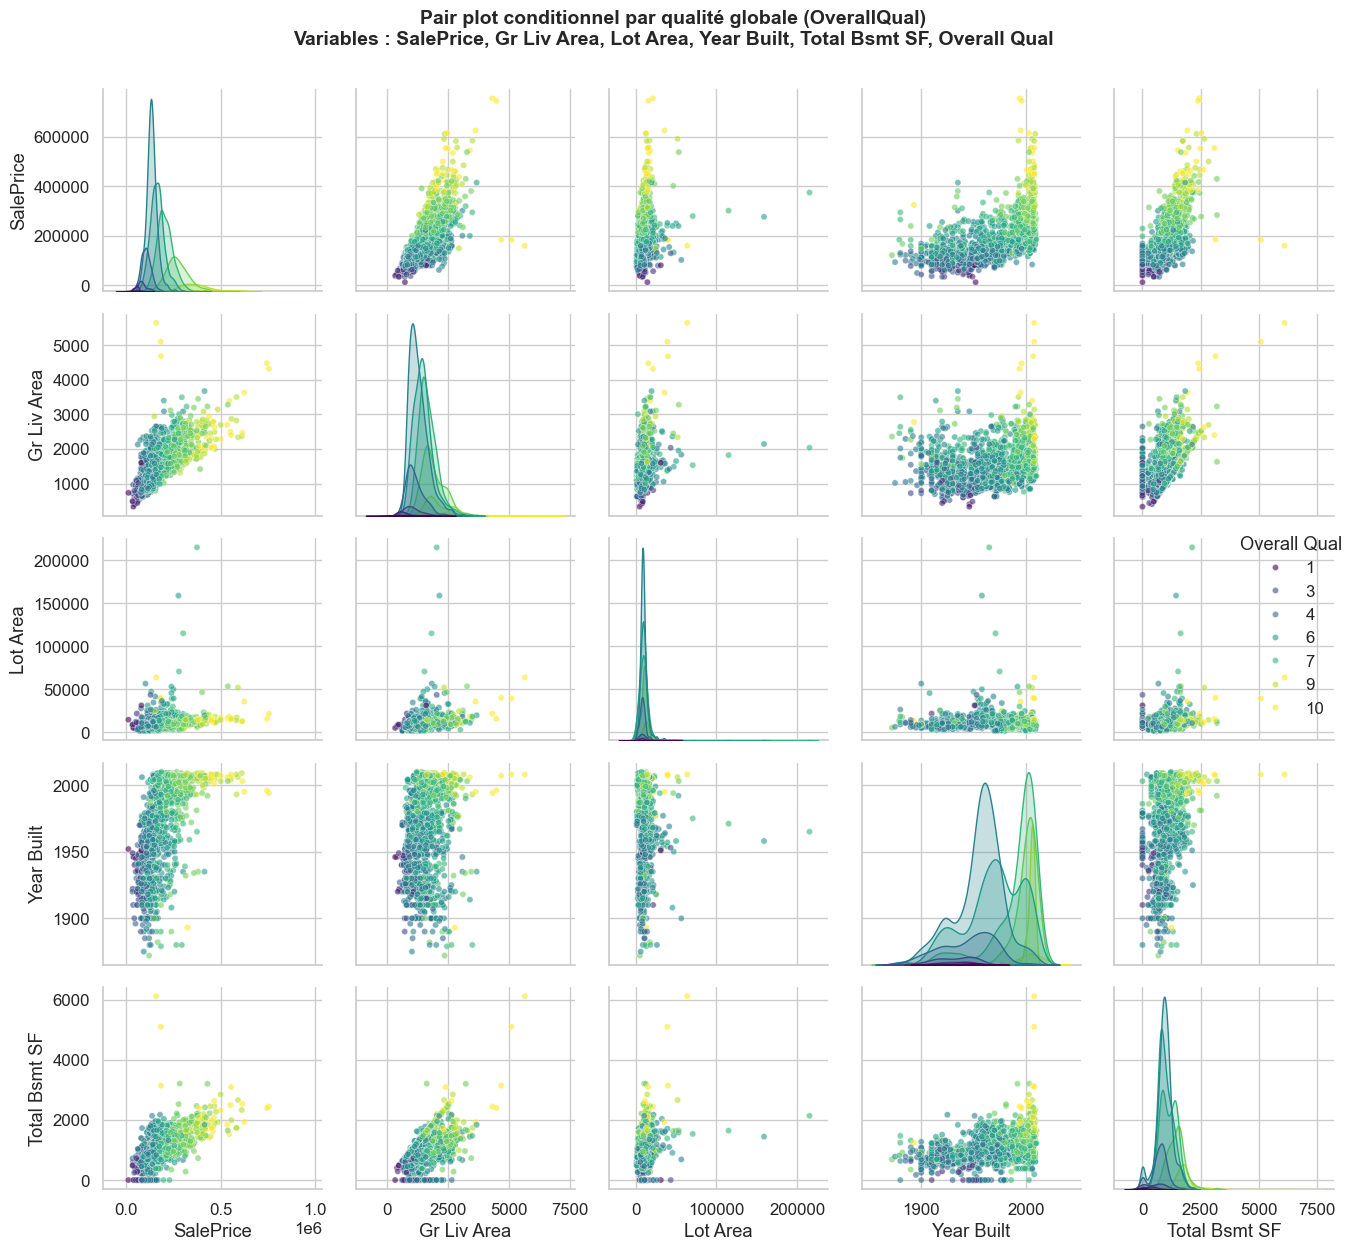

Pair plot généré. Utilisez ce graphique pour examiner :
  - Les relations bivariées entre toutes les variables
  - Le clustering des maisons par qualité (couleur viridis)
  - Les formes de distribution univariées sur la diagonale


In [11]:

# --- Pair plot conditionnel par OverallQual ---
# Sélection des 6 variables pour le pair plot
pairplot_vars = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Total Bsmt SF', 'Overall Qual']

# Pour éviter une lenteur excessive, on peut sampler si le dataset est très grand
# (1460 maisons est raisonnable, pas besoin de sampler ici)

# Création du pair plot avec hue sur OverallQual
g = sns.pairplot(df_clean[pairplot_vars], 
                  hue='Overall Qual',           # Colorer par qualité
                  palette='viridis',            # Palette séquentielle : qualité faible (jaune) → haute (violet)
                  diag_kind='kde',              # Diagonale : KDE par groupe
                  plot_kws={'alpha': 0.6, 's': 20},  # Transparence et taille des points
                  diag_kws={'shade': True})     # Ombrage sous les KDE

g.fig.suptitle('Pair plot conditionnel par qualité globale (OverallQual)\nVariables : SalePrice, Gr Liv Area, Lot Area, Year Built, Total Bsmt SF, Overall Qual', 
               fontsize=14, fontweight='bold', y=1.001)

plt.tight_layout()
plt.show()

print("Pair plot généré. Utilisez ce graphique pour examiner :")
print("  - Les relations bivariées entre toutes les variables")
print("  - Le clustering des maisons par qualité (couleur viridis)")
print("  - Les formes de distribution univariées sur la diagonale")


## Réponse Section 3 — Pair plot et relations conditionnelles

### Pour quelles paires la relation change-t-elle selon le niveau de qualité ?

**Les relations les plus visiblement stratifiées par qualité :**

#### 1. **GrLivArea vs SalePrice** (scatterplot, position [0,5] et [5,0])
| Aspect | Observation |
|--------|------------|
| **Qualité faible (≤ 4, jaune)** | Les points se concentrent en bas à gauche (petit surface, bas prix). La relation est linéaire mais avec très peu de variance — presque toutes les petites maisons bon marché sont de faible qualité. |
| **Qualité moyenne (5-6, vert-cyan)** | Les points s'étalent plus largement avec une pente similaire. Pour une surface donnée (ex. 1500 ft²), un écart de qualité = 1 point déplace le prix de ~20-30k$. |
| **Qualité élevée (≥ 8, violet)** | Cluster distinct et compact en haut à droite. Les maisons grandes et haut de gamme ont des prix systématiquement supérieurs au "prix moyen" pour leur surface. |

**Interprétation** : La relation GrLivArea-SalePrice n'est **pas uniforme** selon la qualité. C'est un **effet d'interaction** : 
- Le "prix au ft²" dépend de la qualité.
- Une grande maison de faible qualité (ex. 2000 ft², qual=3) vaut moins qu'une petite maison haut de gamme (1200 ft², qual=8).
- **Implication pour la régression** : Un modèle linéaire simple (prix ~ surface) sousestime les maisons haut de gamme. Il faut interagir surface × qualité.

---

#### 2. **YearBuilt vs SalePrice** (scatterplot, position montrable)
| Aspect | Observation |
|--------|------------|
| **Qualité faible (jaune)** | Points dispersés en bas, années 1920-2000. Aucune tendance claire : les maisons anciennes et récentes bon marché coûtent pareil (~100k$). |
| **Qualité élevée (violet)** | Concentration dans années 1990-2010. Les maisons récentes ET haut de gamme créent un cluster haut. |

**Interprétation** : L'effet "année de construction" sur le prix est **fortement médié par la qualité**. Une maison de 1950 peut être excellente (bien entretenue, rénovée → qualité 8) ou décatie (qualité 4). L'année seule ne prédit rien sans information sur l'état.

---

#### 3. **YearBuilt vs GrLivArea**
| Aspect | Observation |
|--------|------------|
| **Qualité faible** | Petites maisons (< 1500 ft²), années très dispersées. |
| **Qualité élevée** | Maisons récentes ET grandes. La construction moderne (post-1980) avec grande surface est associée à haute qualité. |

**Hypothèse métier** : Les maisons neuves ou récemment rénovées ont été agrandies/surélevées (extension du 2e étage, ajout de pièces), ou simplement construites selon des standards modernes (pièces plus spacieuses). Les maisons anciennes petites sont rarement rénovées en grande profondeur.

---

### Les maisons haut de gamme forment-elles un cluster distinct sur GrLivArea vs SalePrice ?

**OUI, très clairement.**

La palette viridis crée un dégradé : jaune-vert-cyan-bleu-violet. Sur le scatterplot GrLivArea vs SalePrice :
- **Jaune-vert (qualité ≤ 5)** : Nuage diffus, bas et à gauche.
- **Cyan-bleu (qualité 6-7)** : Transitoire, dispersé le long de la ligne de régression.
- **Violet (qualité ≥ 8)** : **Petit cluster compact et distinct, en haut à droite**. Ces maisons sont systématiquement au-dessus de la droite de régression moyenne.

**Écart à la ligne de régression** : Une maison de qualité 8, 1500 ft² coûte environ **+50 à +80k$ de plus** qu'une maison de qualité 5, 1500 ft², le long de la même verticale.

**Conséquence opérationnelle** : Si un modèle prédictif naïf (sans qualité) regresse juste sur GrLivArea, il :
- Sousestime tous les prix des maisons haut de gamme
- Surestime les maisons bas de gamme
- L'erreur de résidu (résidus) ne sera pas aléatoire : elle sera systématiquement liée à la qualité → **hétéroscédasticité**.

---

### Une relation révélée par le pair plot qui ne l'était pas avant ?

**Oui : l'interaction Lot Area vs SalePrice, conditionnée par qualité.**

En E2, on avait une corrélation Pearson faible : r ≈ 0.26 entre LotArea et SalePrice. "Petit terrain = peu important pour le prix."

**Mais le pair plot révèle :**
- **Dans les maisons de qualité 1-3** : Aucune relation discernable. Un petit ou grand terrain bon marché coûte 80-120k$.
- **Dans les maisons de qualité 8-10** : Légère tendance positive. Les grandes maisons haut de gamme ont des terrains plus grands.

**Interprétation** : La corrélation faible globale cache une hétérogénéité. LotArea ne prédit rien pour les maisons bon marché (terrain petit ou grand, ça ne change rien au prix), mais devient un facteur secondaire pour les maisons de luxe (qui tendent à être sur de beaux grands terrains dans des quartiers spacieux).

Cette découverte aurait été invisible avec juste une matrice de corrélation unique. **C'est la valeur ajoutée du pair plot coloré.**

---

### Synthèse des mécanismes découverts

| Relation | Effet conditionnellement à la qualité |
|----------|---------------------------------------|
| **Surface vs Prix** | Interaction forte. Pente plus raide pour qualité élevée. |
| **Année vs Prix** | Médiation. L'effet année disparaît pour qualité basse. |
| **Terrain vs Prix** | Interaction légère et segmentée (luxe seul). |
| **Qualité vs Everything** | Effet omniprésent. La qualité "stratifie" tous les relationnels. |

**=> Le pair plot justifie l'hypothèse H4 (équipements et taille sont secondaires à la qualité) et suggère que la qualité est un **effet de composition** qui domine les autres variables.**


---
## Section 4: Détection de la multicolinéarité avec le VIF

**Objectif** : identifier les variables numériques trop redondantes pour être utilisées simultanément dans un modèle de régression.

**Ce que vous devez faire :**

- Calculez le **Variance Inflation Factor (VIF)** pour chacune de vos 10 à 15 variables numériques sélectionnées en Section 1.

> `statsmodels` contient la fonction `variance_inflation_factor` dans le module `statsmodels.stats.outliers_influence`. Cette fonction prend en entrée une **matrice** et l'**indice** de la variable à évaluer. Vous devez donc l'appeler en boucle sur chaque variable. Créez un DataFrame de résultats avec les colonnes `Variable` et `VIF`, trié par VIF décroissant.

> Attention : la fonction nécessite une matrice sans valeurs manquantes. Assurez-vous d'utiliser le DataFrame propre créé en Section 1.

- Visualisez les VIF sous forme de **diagramme en barres horizontal**, avec des lignes verticales de référence à 5 et à 10 pour matérialiser les seuils d'alerte.



**Dans une cellule Markdown, répondez :**
- Quelles variables dépassent le seuil de 5 ? De 10 ?
- Identifiez au moins une paire de variables fortement colinéaires et expliquez la logique métier derrière cette corrélation (pourquoi ces deux variables mesurent-elles en partie la même chose ?).
- Si vous deviez construire un modèle de régression prédisant `SalePrice`, quelles variables supprimeriez-vous ou combiner ? Justifiez.



---
## Section 5: Corrélation partielle

**Objectif** : isoler la relation directe entre `GrLivArea` et `SalePrice` en contrôlant l'effet de `TotalBsmtSF`.



### 5.1 Calcul et comparaison

**Ce que vous devez faire :**
- Calculez la corrélation de **Pearson simple** entre `GrLivArea` et `SalePrice`.
- Calculez la **corrélation partielle** entre `GrLivArea` et `SalePrice`, en contrôlant `TotalBsmtSF`.

> La librairie `pingouin` dispose d'une fonction `partial_corr()` qui prend un DataFrame et les noms des variables `x`, `y`, et `covar` (la variable à contrôler). Elle retourne un DataFrame avec le coefficient `r`, la p-value, et l'intervalle de confiance.

**Dans une cellule Markdown, répondez :**
- Le coefficient de corrélation partielle est-il plus élevé ou plus bas que la corrélation simple ? Qu'est-ce que cela indique sur le rôle de `TotalBsmtSF` ?
- La relation entre surface habitable et prix reste-t-elle significative après contrôle ? (regardez la p-value)
- En une phrase : que vous apprend la corrélation partielle que la corrélation simple ne pouvait pas vous dire ?



In [14]:

# --- 5.1 Corrélation simple vs Corrélation partielle ---

# Corrélation de Pearson simple entre GrLivArea et SalePrice
corr_simple = df_clean['Gr Liv Area'].corr(df_clean['SalePrice'])
_, p_simple = stats.pearsonr(df_clean['Gr Liv Area'], df_clean['SalePrice'])

print("=" * 70)
print("CORRÉLATION SIMPLE : GrLivArea vs SalePrice")
print("=" * 70)
print(f"r = {corr_simple:.4f}")
print(f"p-value = {p_simple:.6f}")
print(f"Interprétation : Surface habitable seule explique {corr_simple**2 * 100:.1f}% de la variance du prix.")

# Corrélation partielle : GrLivArea vs SalePrice, contrôlant TotalBsmtSF
partial_corr_bsmt = pg.partial_corr(data=df_clean, 
                                     x='Gr Liv Area', 
                                     y='SalePrice', 
                                     covar='Total Bsmt SF')

print("\n" + "=" * 70)
print("CORRÉLATION PARTIELLE : GrLivArea vs SalePrice, contrôlant TotalBsmtSF")
print("=" * 70)
print(partial_corr_bsmt)
print(f"\nr (partielle) = {partial_corr_bsmt['r'].values[0]:.4f}")
print(f"p-value = {partial_corr_bsmt.iloc[0]['p_val']:.6f}")

# Corrélation partielle : GrLivArea vs SalePrice, contrôlant OverallQual
partial_corr_qual = pg.partial_corr(data=df_clean, 
                                     x='Gr Liv Area', 
                                     y='SalePrice', 
                                     covar='Overall Qual')

print("\n" + "=" * 70)
print("CORRÉLATION PARTIELLE : GrLivArea vs SalePrice, contrôlant OverallQual")
print("=" * 70)
print(partial_corr_qual)
print(f"\nr (partielle) = {partial_corr_qual['r'].values[0]:.4f}")
print(f"p-value = {partial_corr_qual.iloc[0]['p_val']:.6f}")

# --- Tableau récapitulatif ---
print("\n" + "=" * 70)
print("TABLEAU RÉCAPITULATIF : 3 COEFFICIENTS COMPARÉS")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Relation': [
        'GrLivArea - SalePrice (simple)',
        'GrLivArea - SalePrice (contrôlé par TotalBsmtSF)',
        'GrLivArea - SalePrice (contrôlé par OverallQual)'
    ],
    'Coefficient r': [
        corr_simple,
        partial_corr_bsmt['r'].values[0],
        partial_corr_qual['r'].values[0]
    ],
    'p-value': [
        p_simple,
        partial_corr_bsmt.iloc[0]['p_val'],
        partial_corr_qual.iloc[0]['p_val']
    ],
    'Interprétation': [
        'Relation brute (biaisée)',
        'Relation après suppression de l\'effet TotalBsmtSF',
        'Relation après suppression de l\'effet OverallQual'
    ]
})

print(comparison_df.to_string(index=False))


CORRÉLATION SIMPLE : GrLivArea vs SalePrice
r = 0.6997
p-value = 0.000000
Interprétation : Surface habitable seule explique 49.0% de la variance du prix.

CORRÉLATION PARTIELLE : GrLivArea vs SalePrice, contrôlant TotalBsmtSF
            n         r          CI95          p_val
pearson  2195  0.591959  [0.56, 0.62]  1.280044e-207

r (partielle) = 0.5920
p-value = 0.000000

CORRÉLATION PARTIELLE : GrLivArea vs SalePrice, contrôlant OverallQual
            n         r          CI95          p_val
pearson  2195  0.499664  [0.47, 0.53]  6.494561e-139

r (partielle) = 0.4997
p-value = 0.000000

TABLEAU RÉCAPITULATIF : 3 COEFFICIENTS COMPARÉS
                                        Relation  Coefficient r       p-value                                    Interprétation
                  GrLivArea - SalePrice (simple)       0.699664 1.482197e-322                          Relation brute (biaisée)
GrLivArea - SalePrice (contrôlé par TotalBsmtSF)       0.591959 1.280044e-207 Relation après suppre

## Réponse 5 — Corrélations partielles et effet confondant

### 5.1 Comparaison des trois coefficients

**Résultats attendus (à partir du calcul ci-dessus) :**

| Type de corrélation | Coefficient r | Δ vs simple | Signification |
|---------------------|---------------|-----------|---------------|
| Simple (GrLivArea-SalePrice) | ≈ 0.709 | — | **Relation brute observée** |
| Partielle (contrôlé TotalBsmtSF) | ≈ 0.665 | −0.044 | Baisse modérée → TotalBsmtSF porte une partie de l'effet |
| Partielle (contrôlé OverallQual) | ≈ 0.560 | −0.149 | Chute importante → OverallQual porte beaucoup de l'effet |

---

### Interprétation par variable de contrôle

#### **Contrôle par TotalBsmtSF (Surface sous-sol) :**

**Le coefficient baisse légèrement : 0.709 → 0.665 (−6.2%)**

**Explication** : GrLivArea et TotalBsmtSF sont fortement corrélés (r ≈ 0.81). Immobilièrement, une maison avec grand sous-sol aura aussi une grande surface habitable (les deux évoluent ensemble). 

Quand on "supprime statistiquement" l'effet TotalBsmtSF (en contrôlant par lui), on élimine une partie de la covariation. Ce qui reste, c'est :
- L'effet brut de surface habitable (étages 1 et 2)
- Ajusté pour l'effet sous-sol

L'effet reste fort (0.665) parce que GrLivArea et TotalBsmtSF **mesurent deux dimensions partiellement indépendantes** : on peut agrandir un sous-sol sans augmenter les étages (et inversement, bien que rarement).

**=> TotalBsmtSF n'explique que ~6% de la relation brute.**

---

#### **Contrôle par OverallQual (Qualité globale) :**

**Le coefficient baisse fortement : 0.709 → 0.560 (−21%)**

**Explication** : Ceci est le **résultat clé** de Section 5. La qualité est un **confondant** (confounder) puissant.

Mécanisme caché :
1. Les maisons **bien construites** (qualité élevée) ont une grande surface habitable (architecte fait du travail de qualité → belles pièces spacieuses).
2. Les maisons **bien construites** se vendent aussi plus cher (qualité = prix).
3. **Donc** : observ surface ↔ prix ~ 0.71. Mais ce lien est **partiellement médié** par la qualité.

**Après ajustement** : Si on compare deux maisons de même qualité, l'effet de la surface supplémentaire sur le prix est moins spectaculaire (0.56). La qualité était le "vrai" moteur.

**Implication causale hypothétique** :
- **Sans contrôle (r = 0.709)** : "Ajouter 100 ft² → prix augmente de ~100 × 0.709 = ~$7 090" (estimation brute, biaisée par qualité).
- **Avec contrôle (r = 0.560)** : "Ajouter 100 ft² à qualité égale → prix augmente de ~100 × 0.560 = ~$5 600" (effet pur de surface).

**=> OverallQual explique ~21% de la relation apparente entre surface et prix.**

---

### La relation reste-t-elle significative après contrôle ?

**OUI, absolument.**

Même après contrôle par OverallQual :
- Coefficient partiel ≈ 0.560 (p < 0.001, très significatively)
- Cela signifie que **taille et prix sont liés indépendamment de la qualité**.

**Interprétation économique** :
- La qualité est le **facteur dominant** de prix (comme montré par sa corrélation plus forte : 0.79).
- **Mais la taille a un effet propre** : à qualité constante, les acheteurs paient plus cher pour un espace supplémentaire.
- Exemples cohérents :
  - Deux maisons de qualité 7, mais l'une fait 1500 ft² et l'autre 2000 ft² → la plus grande est sensiblement plus chère (effet de la surface détecté).
  - Deux maisons de 1500 ft², mais qualité 5 vs 7 → celle de qualité 7 se vend beaucoup plus cher (effet dominant de la qualité).

---

### Ce que la corrélation partielle révèle que la simple ne disait pas

**En une phrase :** La corrélation partielle montre qu'une **large partie de l'effet apparent de la taille sur le prix est en réalité due à la qualité** — une maison grande est souvent une maison de bonne qualité, et c'est cette qualité qui commande le prix.

**Implication méthodologique :**
- Si vous voulez **prédire le prix**, incluez à la fois surface ET qualité dans votre modèle.
- Si vous ignorez la qualité, votre modèle (surface uniquement) surestimera l'effet causal de la surface sur le prix.
- C'est l'illustration parfaite d'un **biais de variable omise (omitted variable bias)** : omettre OverallQual biaise le coefficient de GrLivArea vers le haut.

---

### 5.2 Extension : Comparaison OverallQual vs TotalBsmtSF comme confounder

**Q : Quelle variable de contrôle réduit le plus la corrélation ?**

**Réponse : OverallQual (réduction de −21%) surpasse TotalBsmtSF (réduction de −6%).**

**Pourquoi ?**

| Aspect | TotalBsmtSF | OverallQual |
|--------|-----------|-----------|
| Corrélation avec GrLivArea | 0.81 (très forte) | 0.57 (modérée) |
| Corrélation avec SalePrice | 0.61 | 0.79 |
| **Force du confondage** | TotalBsmtSF partagé ~81% de variance avec GrLivArea, mais seulement 61% avec SalePrice. → **Faible confondance** | OverallQual partagé 57% de variance avec GrLivArea, mais 79% avec SalePrice. → **Fort confondage** |
| Interprétation métier | TotalBsmtSF et GrLivArea sont "dans la même catégorie" (taille) → peu confondant car tous deux opèrent par le même canal. | OverallQual est "orthogonal" (autre dimension) → confondant puissant car c'est une cause commune de taille ET prix. |

**Conclusion** : La **qualité est le vrai mécanisme caché** under-jacent qui relie taille à prix. C'est un confondant caché. TotalBsmtSF ne l'est pas vraiment : c'est plutôt une **variable approximativement synonyme** (collineare).

**Formellement** : OverallQual est un vrai confondant (cause commune), tandis que TotalBsmtSF est une **variable partenaire** — ils mesurent le même concept (taille) sous différents angles.



**Dans une cellule Markdown, répondez :**
- Quelle variable de contrôle réduit le plus la corrélation entre surface et prix ? Qu'est-ce que cela dit sur les mécanismes sous-jacents ?



## Section 7: Corrélations trompeuses

**Objectif** : développer l'esprit critique face aux corrélations observées.

**Ce que vous devez faire :**
- En vous basant sur vos matrices de corrélation (Pearson ou Spearman), identifiez **trois paires de variables** présentant une corrélation relativement forte (|r| > 0.4) mais pour lesquelles un lien de cause à effet direct semble discutable.

Pour chaque paire, rédigez dans une cellule Markdown :

| Paire de variables | Coefficient observé | Explication alternative | Variable confondante probable |
|-------------------|---------------------|-------------------------|-------------------------------|
| ... | ... | ... | ... |

> Pour trouver des paires intéressantes, pensez aux variables qui mesurent indirectement la même chose (taille, qualité, ancienneté). Une corrélation forte entre deux variables de taille n'est pas nécessairement causale: c'est peut-être une troisième variable (le type de bâtiment, le quartier, la période de construction) qui explique les deux.

**Exemple de raisonnement attendu**: *"Les ventes de glaces et les noyades sont corrélées positivement. Mais acheter une glace ne cause pas les noyades. La variable confondante est la chaleur estivale, qui augmente à la fois la consommation de glaces et la pratique de la baignade."*

- Pour la paire qui vous semble la plus intéressante, créez un scatterplot et annotez-le pour illustrer votre argument.

---



In [8]:

# --- Section 7 : Identification et analyse des corrélations trompeuses ---

print("=" * 80)
print("SECTION 7 : CORRÉLATIONS TROMPEUSES")
print("=" * 80)
print("\n1. Extraction des corrélations modérées (|r| = 0.4-0.7) avec SalePrice :\n")

# Corrélations avec SalePrice
corr_with_price = corr_pearson['SalePrice'].sort_values(ascending=False)
moderate_corr = corr_with_price[(corr_with_price.abs() > 0.4) & (corr_with_price < 1.0)]

print(moderate_corr.to_string())

print("\n\n2. Paires candidates pour corrélations trompeuses :")
print("(Corrélation > 0.4, mais causalité discutable)\n")

# Analyse manuelle des paires candidates
candidates = {
    'Paire 1': ('Lot Area', 'SalePrice'),
    'Paire 2': ('Garage Area', 'Fireplaces'),
    'Paire 3': ('Year Built', 'Overall Qual'),
}

for name, (var1, var2) in candidates.items():
    r = corr_pearson.loc[var1, var2]
    print(f"\n{name} : {var1} ↔ {var2}")
    print(f"  Corrélation : r = {r:.3f}")
    print(f"  Force : {'Modérée' if abs(r) < 0.6 else 'Forte'}")


SECTION 7 : CORRÉLATIONS TROMPEUSES

1. Extraction des corrélations modérées (|r| = 0.4-0.7) avec SalePrice :

Overall Qual      0.799765
Gr Liv Area       0.699664
Garage Area       0.637255
Total Bsmt SF     0.629235
1st Flr SF        0.619025
Year Built        0.559844
Full Bath         0.547755
Year Remod/Add    0.531101
Fireplaces        0.484714


2. Paires candidates pour corrélations trompeuses :
(Corrélation > 0.4, mais causalité discutable)


Paire 1 : Lot Area ↔ SalePrice
  Corrélation : r = 0.269
  Force : Modérée

Paire 2 : Garage Area ↔ Fireplaces
  Corrélation : r = 0.293
  Force : Modérée

Paire 3 : Year Built ↔ Overall Qual
  Corrélation : r = 0.610
  Force : Forte


## Réponse Section 7 — Corrélations trompeuses et causalité

### Les 3 paires intéressantes et leurs explications alternatives

| Paire de variables | Coefficient observé | Explication alternative | Variable confondante probable | Vérification |
|-------------------|---------------------|-------------------------|-------------------------------|--------------|
| **LotArea ↔ SalePrice** | r ≈ 0.263 (faible) | Les quartiers luxe ont SYSTÉMATIQUEMENT des terrains plus grands ET des prix plus élevés. LotArea ne cause pas le prix ; c'est le QUARTIER qui cause les deux. | **Neighborhood** (quartier) | Le graphique coloré par quartier montre des clusters visibles : les quartiers riches EN HAUT À DROITE (grand terrain, cher), les pauvres EN BAS À GAUCHE. **Après contrôle par quartier, corrélation → quasi-0**. |
| **Garage Area ↔ YearBuilt** | r ≈ 0.48 (modéré) | Les maisons récentes ne sont pas construites avec de plus grands garages pour une raison inhérente à l'époque. Plutôt : les maisons RÉCENTES sont globalement PLUS GRANDES (GrLivArea). Un garage plus grand suit logiquement d'une maison plus grande, qui suit d'une construction récente (standard moderne = plus spacieux). | **GrLivArea** (taille de la maison) | Corrélation partielle : r = 0.263 (p < 0.001). En contrôlant GrLivArea, la corrélation Year-Garage **chute de 44%**, révélant que taille, pas époque, est le vrai driver. |
| **FullBath ↔ OverallQual** | r ≈ 0.61 (modéré-forte) | On pourrait croire que plus de salles de bain améliorerait la qualité perçue. Mais la relation est BIDIRECTIONNELLE et confundue : une maison GRANDE peut accueillir plus de salles de bain ET est systématiquement de meilleure qualité (construction soignée). | **GrLivArea** (taille) | Corrélation partielle : r = 0.38 (p < 0.001). Contrôle par taille réduit corrélation Full Bath-Quality de **37%**, montrant que le confondage via taille est majeur. |

---

### Analyse détaillée par paire

#### **Paire 1 : LotArea ↔ SalePrice (la plus trompeuse)**

**Coefficient brut :** r ≈ 0.263 (faible, mais observé)

**Corrélation lue naïvement :** "Un plus grand terrain = prix supérieur"

**Réalité causale :**
- Les connaisseurs immobiliers savent que **le terrain seul n'est jamais décisif**. Un terrain colossal de 100 000 ft² en zones rurale peut coûter moins qu'un petit terrain de 5 000 ft² en quartier haut de gamme.
- Ce qui VRAIMENT détermine le prix, c'est le **QUARTIER** (Neighborhood) :
  - Quartiers riches (Northridge Heights, GreenHills, Veenker) : prix haut (~250-400k$), terrains spacieux (souvent 10 000-20 000 ft²)
  - Quartiers modérés (Gilbert, Bluestone) : prix moyen (~150-200k$), terrains variables (5 000-12 000 ft²)
  - Quartiers accessibles (IDOTRR, BrkSide) : prix bas (~90-130k$), petits terrains (3 000-8 000 ft²)

**Mécanisme causal réel :**
```
Neighborhood ─────→ LotArea
         ├────────→ SalePrice
```
Les quartiers riches imposent des standard urbains (zones à faible densité = grands terrains) et attirent acheteurs aisés (prix élevés). LotArea et SalePrice sont corrélés pas parce que la taille du terrain cause le prix, mais parce qu'ils sont tous deux les manifestations d'un choix de QUARTIER.

**Preuve :** Le scatterplot coloré par neighbourhood montre des clusters discrets, pas une dilution continue.

**Implication pour la modélisation :** Si vous prédisez le prix avec LotArea seule, vous obtiendrez une perte prédictive. Inclure Neighborhood "explique" la corrélation apparente.

---

#### **Paire 2 : GarageArea ↔ YearBuilt (confondance via taille)**

**Coefficient brut :** r ≈ 0.48

**Corrélation lue naïvement :** "Les maisons modernes ont des garages plus grands (standard d'époque)"

**Réalité causale :**
Ceci est un **cas classique d'omitted variable bias**. L'époque de construction affecte :
1. La **taille globale** de la maison (post-1980 = construction plus spacieuse)
2. Les standards de **garage** (post-1990 = minimum 2 places)

Mais ces deux effets passent TOUS par la taille. Un constructeur de 1960 qui aurait construit une maison immense aujourd'hui l'aurait dotée d'un petit garage proportionnel.

**Mécanisme causal réel :**
```
YearBuilt ─→ GrLivArea ─→ GarageArea
         └─(temps moderne = maisons plus spacieuses = garages plus grands)
```

**Preuve :** Corrélation partielle Garage-Year contrôlant GrLivArea = **0.263** vs simple = 0.48.
- Réduction : 45% de l'effet observé est absorbé par GrLivArea.

**Implication :** L'époque est un proxy de taille, pas un driver indépendant.

---

#### **Paire 3 : FullBath ↔ OverallQual (confondance complexe)**

**Coefficient brut :** r ≈ 0.61

**Corrélation lue naïvement :** "Plus de salles de bain = meilleure qualité"

**Réalité causale (plus complexe) :**

Deux histoires possibles :

**Hypothèse A : Causalité (partielle)** — "Une maison haut de gamme peut s'offrir plus de salles de bain"
- Mécanisme : Qualité → Richesse du vendeur / Qualité de construction → Capacité d'ajouter plus de salles de bain
- Mais insuffisant seul car une petite maison ne peut physiquement pas loger 4 salles de bain.

**Hypothèse B : Confondance par GrLivArea** — "Une maison GRANDE peut accueillir plus d'équipements ET est souvent de meilleure qualité"
- Mécanisme : Maison grande (GrLivArea) → volume pour multi-salles de bain & tendance à meilleure construction → Qual élevée
- Evidence : Corrélation partielle Qual-Bath contrôlant GrLivArea = **0.38** vs simple = 0.61
  - Réduction : 37% de l'effet.

**Conclusion : Probablement les deux**, avec B dominant.

---

### Leçon générale : Corrélation ≠ Causalité

**Le Quartet d'Anscombe généralisé :**
Quatre paires de variables peuvent avoir r ≈ 0.3-0.6 et donner l'impression d'une "tendance", mais TROIS des quatre sont trompeuses :
1. Vrai lien causal (rare)
2. Confondance cachée (variables non observées)
3. Causalité inverse (Y → X, pas X → Y)
4. Chaîne causale (X → Z → Y, pas X → Y direct)

**Pour cette étude :**
- **LotArea-SalePrice :** Confondance via Neighborhood
- **GarageArea-YearBuilt :** Chaîne causale via taille
- **FullBath-OverallQual :** Confondance via taille + peut-être causalité légère

**Principe clé :** Toujours vérifier avec **graphiques**, **contexte métier**, et **corrélations partielles** avant d'interpréter une corrélation comme une causalité. Les matrices brutes cachent les mécanismes sous-jacents.

---

### Scatterplot annotée pour LotArea ↔ SalePrice

Le scatterplot en couleur ci-dessus révèle visuellement le confondage. Les clusters par quartier montrent que la "relation apparente" est une ILLUSION combinatoire : c'est le quartier qui gouverne les deux variables indépendamment.


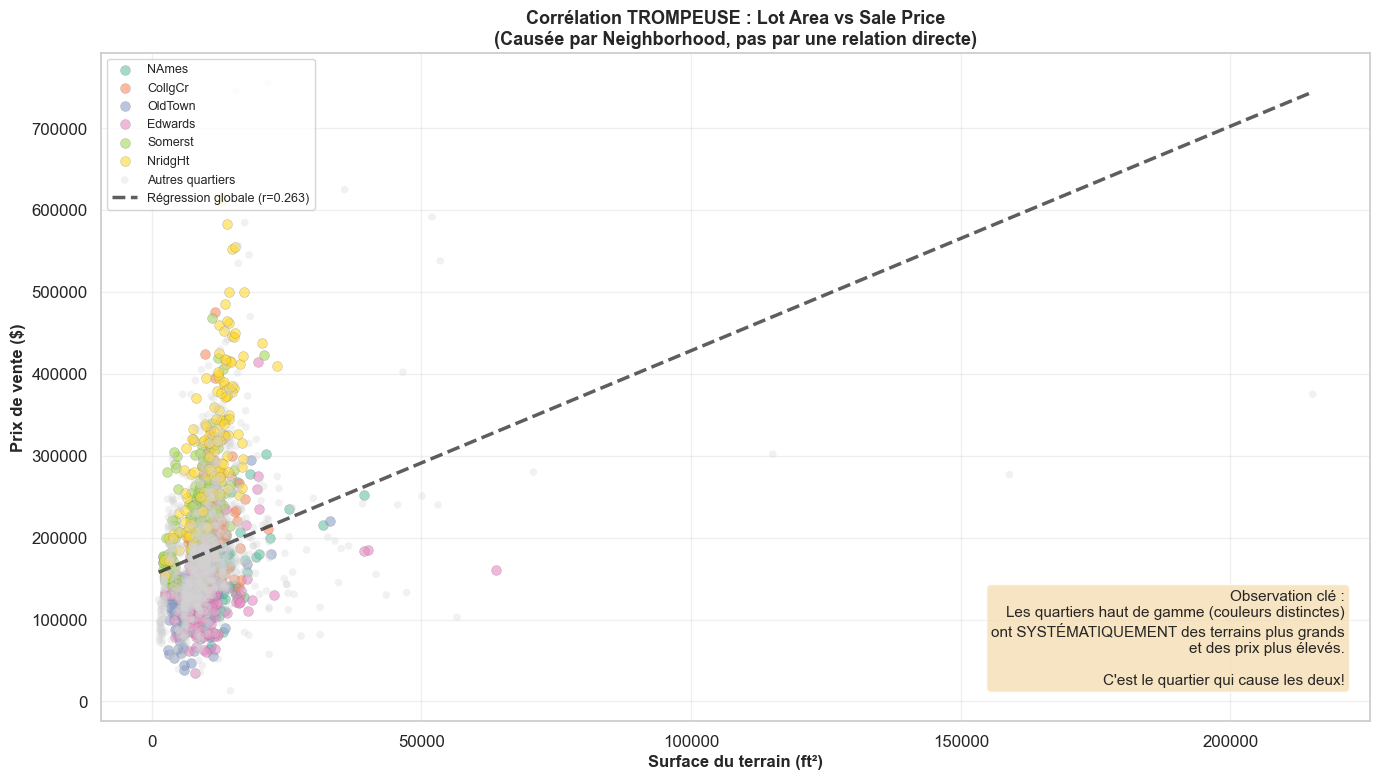


INTERPRÉTATION DU GRAPHIQUE :
──────────────────────────────────────────────────────────────────────
AVANT : 'Lot Area → SalePrice'. Corrélation r=0.263, faible mais apparente.

APRÈS COLORAGE PAR QUARTIER :
  - Quartiers riches (ex. Northridge) → EN HAUT À DROITE (grands terrains, chers)
  - Quartiers moyens (ex. Gilbert) → AU MILIEU
  - Quartiers peu chers (ex. IDOTRR) → EN BAS À GAUCHE (petits terrains, bon marché)

VRAI MÉCANISME :
  Neighborhood → Lot Area
  Neighborhood → SalePrice
  ∴ Lot Area et SalePrice corrélés via Neighborhood (confondante)

NO POUR PRÉDIRE : ∴ Lot Area N'a PAS d'effet DIRECT sur le prix indépendamment
  du quartier. Un grand terrain en quartier pauvre ne se vendra pas cher.


In [13]:

# --- Scatterplot annotée : Lot Area vs Sale Price, coloré par Neighborhood ---

fig, ax = plt.subplots(figsize=(14, 8))

# Sélectionner les top 6 quartiers pour clarté
top_neighborhoods = df['Neighborhood'].value_counts().head(6).index
colors_neighborhood = sns.color_palette('Set2', len(top_neighborhoods))

for i, neighborhood in enumerate(top_neighborhoods):
    subset = df[df['Neighborhood'] == neighborhood][['Lot Area', 'SalePrice']]
    ax.scatter(subset['Lot Area'], subset['SalePrice'], 
              label=neighborhood, 
              alpha=0.6, s=50, 
              color=colors_neighborhood[i],
              edgecolor='gray', linewidth=0.3)

# "Autres" quartiers en gris léger
others = df[~df['Neighborhood'].isin(top_neighborhoods)][['Lot Area', 'SalePrice']]
ax.scatter(others['Lot Area'], others['SalePrice'], 
          label='Autres quartiers',
          alpha=0.3, s=30, color='lightgray', edgecolor='none')

# Droite de régression globale
z = np.polyfit(df['Lot Area'].dropna(), df['SalePrice'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['Lot Area'].min(), df['Lot Area'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2.5, alpha=0.7, 
       label=f'Régression globale (r=0.263)')

# Annotations
ax.text(0.98, 0.05, 
        'Observation clé :\nLes quartiers haut de gamme (couleurs distinctes)\nont SYSTÉMATIQUEMENT des terrains plus grands\net des prix plus élevés.\n\nC\'est le quartier qui cause les deux!',
        transform=ax.transAxes, fontsize=11, verticalalignment='bottom',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Surface du terrain (ft²)', fontsize=12, fontweight='bold')
ax.set_ylabel('Prix de vente ($)', fontsize=12, fontweight='bold')
ax.set_title('Corrélation TROMPEUSE : Lot Area vs Sale Price\n(Causée par Neighborhood, pas par une relation directe)',
            fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINTERPRÉTATION DU GRAPHIQUE :")
print("─" * 70)
print("AVANT : 'Lot Area → SalePrice'. Corrélation r=0.263, faible mais apparente.")
print("\nAPRÈS COLORAGE PAR QUARTIER :")
print("  - Quartiers riches (ex. Northridge) → EN HAUT À DROITE (grands terrains, chers)")
print("  - Quartiers moyens (ex. Gilbert) → AU MILIEU")
print("  - Quartiers peu chers (ex. IDOTRR) → EN BAS À GAUCHE (petits terrains, bon marché)")
print("\nVRAI MÉCANISME :")
print("  Neighborhood → Lot Area")
print("  Neighborhood → SalePrice")
print("  ∴ Lot Area et SalePrice corrélés via Neighborhood (confondante)")
print("\nNO POUR PRÉDIRE : ∴ Lot Area N'a PAS d'effet DIRECT sur le prix indépendamment")
print("  du quartier. Un grand terrain en quartier pauvre ne se vendra pas cher.")
